classify parasitized images (cell has malaria disease) and uninfected images (cells that are not infected with the malaria disease) using resnet18

In [34]:
from torchvision import models
import torch
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
import torch.optim as optim

import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

## Images:
from skimage.transform import resize
from skimage.io import imread

import os
import matplotlib.pyplot as plt
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [36]:
datadir = '.\\Images\\'
categories = ['Parasitized', 'Uninfected']

X = []
y = []

for i in categories:
    print ('loading... category: ', i)
    path = os.path.join (datadir, i)
    print(path)
    for img in os.listdir (path):
        img_array = imread (os.path.join (path, img))
        img_resized = resize (img_array, (224, 224, 3))
        img_tensor = torch.tensor (img_resized).float().to(device) # convert to tensor and send to device (GPU/CPU)
        X.append(img_tensor) # permute to (C, H, W) format and add batch dimension
        y.append (torch.tensor (categories.index(i)).to(device))
    print ("loaded category ", i, "successfully")
    
X = torch.stack(X)  # stack all tensors in a single tensor
y = torch.stack(y)  # stack all labels in a single tensor
X.shape, y.shape

loading... category:  Parasitized
.\Images\Parasitized
loaded category  Parasitized successfully
loading... category:  Uninfected
.\Images\Uninfected
loaded category  Uninfected successfully


(torch.Size([479, 224, 224, 3]), torch.Size([479]))

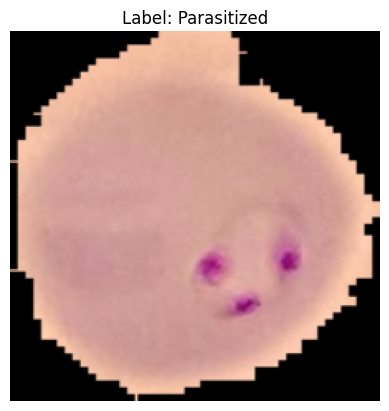

In [37]:
plt.imshow(X[0].cpu().numpy()) # visualize the first image in the dataset
plt.title(f'Label: {categories[y[0].item()]}')
plt.axis('off') # Hide the axis to make the image clearer
plt.show()

In [38]:
print(X.shape)
X1 = X.permute(0, 3, 1, 2)
print(X1.shape)

torch.Size([479, 224, 224, 3])
torch.Size([479, 3, 224, 224])


In [39]:
X_train, X_test, y_train, y_test = train_test_split (X1, y, test_size=0.2, random_state=42) # 80% training and 20% testing
print ("Train shape: ", X_train.shape, y_train.shape)
print ("Test shape: ", X_test.shape, y_test.shape)


Train shape:  torch.Size([383, 3, 224, 224]) torch.Size([383])
Test shape:  torch.Size([96, 3, 224, 224]) torch.Size([96])


In [40]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)   
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(categories))
model = model.to(device)

In [41]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [58]:
epochs = 64
bs = 16
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train, y_train)
dataloader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=bs, shuffle=False)
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

Epoch 1/64, Loss: 2.4086
Epoch 2/64, Loss: 1.5017
Epoch 3/64, Loss: 0.6015
Epoch 4/64, Loss: 0.6039
Epoch 5/64, Loss: 0.1723
Epoch 6/64, Loss: 0.4068
Epoch 7/64, Loss: 2.5876
Epoch 8/64, Loss: 2.8196
Epoch 9/64, Loss: 1.9046
Epoch 10/64, Loss: 1.0561
Epoch 11/64, Loss: 1.5502
Epoch 12/64, Loss: 0.5711
Epoch 13/64, Loss: 0.3847
Epoch 14/64, Loss: 0.8958
Epoch 15/64, Loss: 1.3247
Epoch 16/64, Loss: 0.6708
Epoch 17/64, Loss: 1.5656
Epoch 18/64, Loss: 0.8676
Epoch 19/64, Loss: 0.6764
Epoch 20/64, Loss: 0.8024
Epoch 21/64, Loss: 1.0923
Epoch 22/64, Loss: 0.3018
Epoch 23/64, Loss: 0.1920
Epoch 24/64, Loss: 0.1000
Epoch 25/64, Loss: 0.0963
Epoch 26/64, Loss: 0.0480
Epoch 27/64, Loss: 0.0504
Epoch 28/64, Loss: 0.0486
Epoch 29/64, Loss: 0.0281
Epoch 30/64, Loss: 0.0138
Epoch 31/64, Loss: 0.0113
Epoch 32/64, Loss: 0.0402
Epoch 33/64, Loss: 0.0116
Epoch 34/64, Loss: 0.2264
Epoch 35/64, Loss: 0.9350
Epoch 36/64, Loss: 2.5990
Epoch 37/64, Loss: 1.4400
Epoch 38/64, Loss: 0.6404
Epoch 39/64, Loss: 0.

In [60]:
model.eval()
with torch.no_grad():
    train_total = 0
    train_correct = 0

    for inputs, labels in dataloader: # train_dataloader
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        predicted = torch.max(outputs, 1)[1]
        
        train_total += labels.shape[0]
        train_correct += (predicted == labels).sum().item()

    accuracy = train_correct / train_total * 100
    print(f"Correct={train_correct}, Total={train_total}, Test Accuracy: {accuracy:.4f}%")

    test_total = 0
    test_correct = 0
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        
        predicted = torch.max(outputs, 1)[1]
        
        test_total += labels.shape[0]
        test_correct += (predicted == labels).sum().item()

    accuracy = test_correct / test_total * 100
    print(f"Correct={test_correct}, Total={test_total}, Test Accuracy: {accuracy:.4f}%")


Correct=383, Total=383, Test Accuracy: 100.0000%
Correct=95, Total=96, Test Accuracy: 98.9583%


In [61]:
from torchvision import datasets
from torch.utils.data import DataLoader
dataset = datasets.ImageFolder(root=datadir, transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
]))
print("Class mapping:", dataset.classes)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Class mapping: ['Parasitized', 'Uninfected']


Predicted class: Uninfected


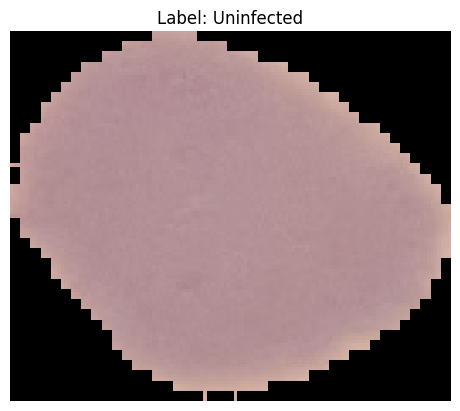

In [62]:
img_array = imread ('./testImage1.png')

img_resized = resize (img_array, (224, 224, 3))

image_tensor = transforms.ToTensor()(img_resized)
image_tensor = image_tensor.unsqueeze(0).float().to(device)

model.eval()

with torch.no_grad():
    outputs = model(image_tensor)
    predicted = torch.argmax(outputs[0])
    print("Predicted class:", categories[predicted.item()])

plt.imshow(img_array) # visualize the first image in the dataset
plt.title(f'Label: {categories[predicted.item()]}')
plt.axis('off') # Hide the axis to make the image clearer
plt.show()

In [63]:
a = torch.tensor([[1, 2, 3], [4, 5, 3], [6, 7, 2], [8, 9, 1]])
b = torch.max(a, 1)
print(b)
print(torch.argmax(a))

torch.return_types.max(
values=tensor([3, 5, 7, 9]),
indices=tensor([2, 1, 1, 1]))
tensor(10)
